# 07 · Video üzerinde tespit
Video = arka arkaya gösterilen kareler. Her kare bir fotoğraf olduğuna göre, bildiğimiz her şey videoda da geçerli.

## 1. Test videosunu üret

Elimizde hazır video yok, kendimiz üreteceğiz: gökyüzü fotoğrafının üstünde **hareket eden bir İHA**.

**Video nedir?** Arka arkaya gösterilen kareler. Her kare tek başına bir fotoğraf, yani `(yükseklik, genişlik, 3)` boyutunda bir NumPy dizisi. Fotoğraf için bildiğimiz her şey videoda da geçerli.

| Kod | Ne yapar |
|---|---|
| `cv2.VideoWriter(dosya, codec, fps, boyut)` | Video dosyası oluşturur. Boyut **(genişlik, yükseklik)** sırasında — `shape`'in tersi |
| `range(100)` | 0'dan 99'a sayar |
| `yazici.write(kare)` | Kareyi videoya ekler |
| `yazici.release()` | Dosyayı kapatır — **şart**, yoksa video bozuk kalır |

**Seçtiğimiz değerler:** 100 kare ve 20 FPS → 5 saniyelik video. İHA soldan sağa giderken aşağı da iniyor (y: 60 → 380): gökyüzünden fotoğrafın alt kısmına doğru.

In [1]:
import cv2
import numpy as np


# =====================================================================
# 1) ARKA PLAN FOTOĞRAFI
#    Videonun her karesinde aynı gökyüzü görünecek. İHA'yı bu fotoğrafın
#    üstünde gezdireceğiz. Bu fotoğrafı seçtik çünkü içinde gerçek İHA'lar
#    var ve model bu tür sahnelerde iyi çalışıyor.
# =====================================================================
iha = cv2.imread("../data/kucuk_paket/images/train/01_uav2uav__430__864a7aebf1.png")

yukseklik, genislik = iha.shape[0], iha.shape[1]   # 512 ve 640
                                                   # shape = (yükseklik, genişlik, kanal)
                                                   # Videonun kare boyutu da bu olmak zorunda:
                                                   # farklı boyutta kare yazmaya çalışırsak
                                                   # video bozuk çıkar.


# =====================================================================
# 2) HAREKET EDECEK İHA PARÇASINI KES
#    Etiket dosyasındaki ilk satırı alıyoruz. Neden ilk satır? Fotoğrafta
#    2 İHA var, birini seçmemiz yeterli. İkisi de olurdu.
# =====================================================================
with open("../data/kucuk_paket/labels/train/01_uav2uav__430__864a7aebf1.txt") as dosya:
    satir = dosya.read().splitlines()[0]     # [0] = dosyanın ilk satırı = ilk nesne

parcalar = satir.split()                     # "4 0.45 0.63 0.09 0.06" → 5 parçalı liste

mx = float(parcalar[1]) * genislik           # [1] merkez x oranı → piksele çevir (yatay → genişlik)
my = float(parcalar[2]) * yukseklik          # [2] merkez y oranı → piksele çevir (dikey → yükseklik)
g  = float(parcalar[3]) * genislik           # [3] kutu genişliği
y  = float(parcalar[4]) * yukseklik          # [4] kutu yüksekliği

x1, y1 = round(mx - g/2), round(my - y/2)    # merkezden yarım boyut geri → sol üst köşe
x2, y2 = round(mx + g/2), round(my + y/2)    # merkezden yarım boyut ileri → sağ alt köşe

parca = iha[y1:y2, x1:x2].copy()             # o bölgeyi kes. [satır, sütun] = [y, x] sırası!
                                             # .copy() şart: dilim bir "pencere"dir, kopyalamazsak
                                             # parçayı değiştirdiğimizde asıl fotoğraf da bozulur.

ph, pw = parca.shape[0], parca.shape[1]      # parçanın yüksekliği (35) ve genişliği (60)
                                             # Yapıştırırken bu ölçüler lazım: hedef bölge
                                             # parçayla birebir aynı boyutta olmak zorunda.


# =====================================================================
# 3) VİDEO YAZICIYI AÇ
#    Video, arka arkaya yazılan karelerden oluşur. VideoWriter bu kareleri
#    tek tek alıp sıkıştırarak dosyaya yazan araç.
# =====================================================================
yazici = cv2.VideoWriter(
    "../outputs/iha_video.mp4",              # NEREYE: outputs klasörü. Burası git'e girmiyor,
                                             # üretilen dosyalar deposu.

    cv2.VideoWriter_fourcc(*"mp4v"),         # CODEC: karelerin nasıl sıkıştırılacağı.
                                             # "mp4v" .mp4 dosyaları için yaygın ve sorunsuz.

    20,                                      # FPS: saniyede 20 kare. 20 seçtik çünkü:
                                             # - 100 kare / 20 fps = 5 saniyelik video (kısa, yeterli)
                                             # - göz için akıcı görünen alt sınır ~15-20 fps

    (genislik, yukseklik)                    # KARE BOYUTU: (640, 512)
                                             # DİKKAT sıra ters! shape (yükseklik, genişlik) verir,
                                             # OpenCV burada (genişlik, yükseklik) ister.
                                             # Ters yazarsan video oluşur ama boş/bozuk çıkar.
)


# =====================================================================
# 4) KARELERİ ÜRET
#    Her turda: temiz arka planı al, İHA'yı yeni konuma yapıştır, videoya yaz.
#    100 kare seçtik: 5 saniyelik video, hem hızlı üretilir hem incelemesi kolay.
# =====================================================================
kare_sayisi = 100

for i in range(kare_sayisi):                 # i = 0, 1, 2, ... 99
    kare = iha.copy()                        # HER TURDA yeniden kopya alıyoruz.
                                             # Almasak önceki karede yapıştırdığımız İHA yerinde
                                             # kalır ve iz bırakırdı.

    # --- yatay konum: soldan sağa ---
    x = 20 + int(i * (genislik - pw - 40) / kare_sayisi)
    #   20            → soldan 20 piksel boşlukla başla (tam kenardan değil)
    #   genislik-pw-40 → gidebileceği toplam mesafe.
    #                    pw çıkarıldı ki parça sağ kenardan taşmasın,
    #                    40 çıkarıldı ki sağda da 20 piksel boşluk kalsın.
    #   i / kare_sayisi → 0'dan 1'e giden oran. i=0'da başta, i=99'da sonda.
    #   int(...)        → piksel tam sayı olmalı

    # --- dikey konum: yukarıdan aşağı ---
    y = 60 + int(i * 320 / kare_sayisi)
    #   60  → gökyüzünün üst kısmından başla
    #   320 → toplam 320 piksel aşağı insin. 512 yükseklikte 60+320=380'e varır,
    #         yani fotoğrafın alt kısmındaki AĞAÇLIK bölgeye ulaşır.
    #         Bunu bilerek seçtik: modelin arka plan değişince ne yaptığını görmek istiyoruz.

    kare[y:y+ph, x:x+pw] = parca             # yapıştır. Sol taraf hedef bölgeyi seçiyor:
                                             # y'den başla ph satır, x'ten başla pw sütun.
                                             # Boyutlar birebir uymak zorunda.

    yazici.write(kare)                       # bu kareyi videoya ekle


# =====================================================================
# 5) DOSYAYI KAPAT
#    release() çağrılmazsa son kareler diske yazılmaz ve video açılmaz.
#    En sık yapılan hatalardan biri.
# =====================================================================
yazici.release()

print("video hazır, kare sayısı:", kare_sayisi)

video hazır, kare sayısı: 100


## 2. Videoyu kare kare işle

`VideoWriter` yazıyordu, **`VideoCapture` okuyor**. Her kare modele ayrı veriliyor, kutulu hali ikinci bir videoya yazılıyor.

**`while True` + `break`:** Kaç kare olduğunu peşinen bilmediğimiz için `for` yerine `while`. `kamera.read()` iki değer döndürür: kare alınabildi mi ve karenin kendisi. Video bitince `False` gelir, `break` döngüyü kırar.

**Sonuç: 100 karenin 100'ünde drone bulundu.**

İHA alttaki ağaçlık bölgeye indiğinde bile kaybetmedi. Sebebi: arka plan hep aynı gökyüzü fotoğrafı; model tüm kareyi "gökyüzü sahnesi" olarak değerlendiriyor. Bağlam, kutunun altındaki birkaç piksel değil **fotoğrafın tamamı**.

In [2]:
from ultralytics import YOLO

model = YOLO("../models/iha_yolo11n.pt")             # kendi eğittiğimiz model


# =====================================================================
# 1) VİDEOYU OKUMAK İÇİN AÇ
#    VideoWriter yazıyordu, VideoCapture okuyor. İkisi birbirinin tersi.
# =====================================================================
kamera = cv2.VideoCapture("../outputs/iha_video.mp4")

toplam_kare = int(kamera.get(cv2.CAP_PROP_FRAME_COUNT))   # videodaki kare sayısı
fps = kamera.get(cv2.CAP_PROP_FPS)                        # saniyedeki kare sayısı
print("kare sayısı:", toplam_kare, "| FPS:", fps)


# =====================================================================
# 2) ÇIKTI VİDEOSUNU AÇ
#    Kutuları çizilmiş halini ayrı bir dosyaya yazacağız.
# =====================================================================
cikti = cv2.VideoWriter(
    "../outputs/iha_video_tespit.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    20,
    (genislik, yukseklik)
)


# =====================================================================
# 3) KARE KARE İŞLE
# =====================================================================
kare_no = 0
bulunan_kareler = []                       # hangi karelerde drone bulundu, biriktireceğiz

while True:                                # "sonsuz" döngü; kırılana kadar dön
    okundu, kare = kamera.read()           # SIRADAKİ kareyi oku
                                           # iki değer döner:
                                           #   okundu → True/False, kare alınabildi mi
                                           #   kare   → görüntünün kendisi (NumPy dizisi)

    if not okundu:                         # video bittiyse okundu=False olur
        break                              # döngüyü kır, çık

    kare_no = kare_no + 1

    sonuc = model(kare, verbose=False)[0]  # bu kareye tahmin yap
                                           # dosya yolu değil, resmin kendisini veriyoruz

    droneler = []                          # bu karedeki drone tahminleri
    for kutu in sonuc.boxes:
        if model.names[int(kutu.cls)] == "drone":
            droneler.append(float(kutu.conf))

    if droneler:                           # liste boş değilse (en az bir drone bulunduysa)
        bulunan_kareler.append(kare_no)

    cikti.write(sonuc.plot())              # kutuları çizilmiş kareyi çıktı videosuna yaz


# =====================================================================
# 4) DOSYALARI KAPAT
# =====================================================================
kamera.release()
cikti.release()

print(f"{kare_no} karenin {len(bulunan_kareler)} tanesinde drone bulundu")

kare sayısı: 100 | FPS: 20.0
100 karenin 100 tanesinde drone bulundu


## 3. Aynı hareket, farklı arka plan

Kontrollü deney: İHA parçası, hareket, kare sayısı ve model aynı. **Değişen tek satır:** `kare = otopark.copy()`.

**Sonuç: 100 karenin 0 tanesinde drone bulundu.**

| Arka plan | Bulunan kare |
|---|---|
| Gökyüzü | **100 / 100** |
| Otopark | **0 / 100** |

06'daki tek karelik kestirme öğrenme deneyinin 100 karelik kanıtı. Videoda arabalar kutulanıyor, İHA kutusuz geziyor.

In [4]:
otopark = cv2.imread("../data/kucuk_paket/images/train/02_hituav__0_100_50_0_08164__c5427da128.png")

# --- 1) videoyu üret: aynı hareket, farklı arka plan ---
yazici2 = cv2.VideoWriter("../outputs/iha_otopark.mp4",
                          cv2.VideoWriter_fourcc(*"mp4v"), 20, (genislik, yukseklik))

for i in range(kare_sayisi):
    kare = otopark.copy()                                  # DEĞİŞEN TEK ŞEY: arka plan
    x = 20 + int(i * (genislik - pw - 40) / kare_sayisi)
    y = 60 + int(i * 320 / kare_sayisi)
    kare[y:y+ph, x:x+pw] = parca
    yazici2.write(kare)

yazici2.release()

# --- 2) tespit et ---
kamera2 = cv2.VideoCapture("../outputs/iha_otopark.mp4")
cikti2 = cv2.VideoWriter("../outputs/iha_otopark_tespit.mp4",
                         cv2.VideoWriter_fourcc(*"mp4v"), 20, (genislik, yukseklik))

kare_no2 = 0
drone_bulunan = 0

while True:
    okundu, kare = kamera2.read()
    if not okundu:
        break
    kare_no2 = kare_no2 + 1

    sonuc = model(kare, verbose=False)[0]

    for kutu in sonuc.boxes:
        if model.names[int(kutu.cls)] == "drone":
            drone_bulunan = drone_bulunan + 1
            break                                          # bu karede bulundu, yeter

    cikti2.write(sonuc.plot())

kamera2.release()
cikti2.release()

print(f"otopark arka planı: {kare_no2} karenin {drone_bulunan} tanesinde drone bulundu")

otopark arka planı: 100 karenin 0 tanesinde drone bulundu


## 4. Parlak zeminde parlak nesne

Soru: İHA parlak bir zemine inerse ne olur — nesne ve arka plan aynı parlaklıktayken iki yöntem nasıl davranır?

**Ölçüm** (İHA otoparkın parlak bölgesine konduğunda):

| | Ortalama parlaklık |
|---|---|
| Otsu eşiği | 104 |
| Yapıştırılan parça | 102.7 |
| Yanındaki asfalt | 123.3 |

Kestiğimiz parça yalnızca İHA değil, **etrafındaki koyu gökyüzüyle birlikte** bir dikdörtgen; parlak asfaltta koyu bir yama gibi duruyor (eşiklemede beyaz oranı %41, asfaltta %63).

**İki yöntem de bulamadı, sebepleri farklı:**

| | Neden |
|---|---|
| Klasik (eşikleme) | Kuralı basit: "parlak = nesne". Bu sahnede asfalt parlak, araç koyu — kural ters dönmüş. |
| YOLO | Kuralı öğrenilmiş: "gökyüzü sahnesinde küçük parlak leke = İHA". Sahne otopark olduğu için uygulamıyor. |

Klasik yöntem **basit olduğu için**, YOLO **yanlış şeyi öğrendiği için** yanılıyor.

*(Gerçek bir "parlak zeminde parlak nesne" testi için İHA'nın yalnızca kendi piksellerini kesmek gerekir — maskeleme, ileri konu.)*

YOLO → drone tahminleri: YOK


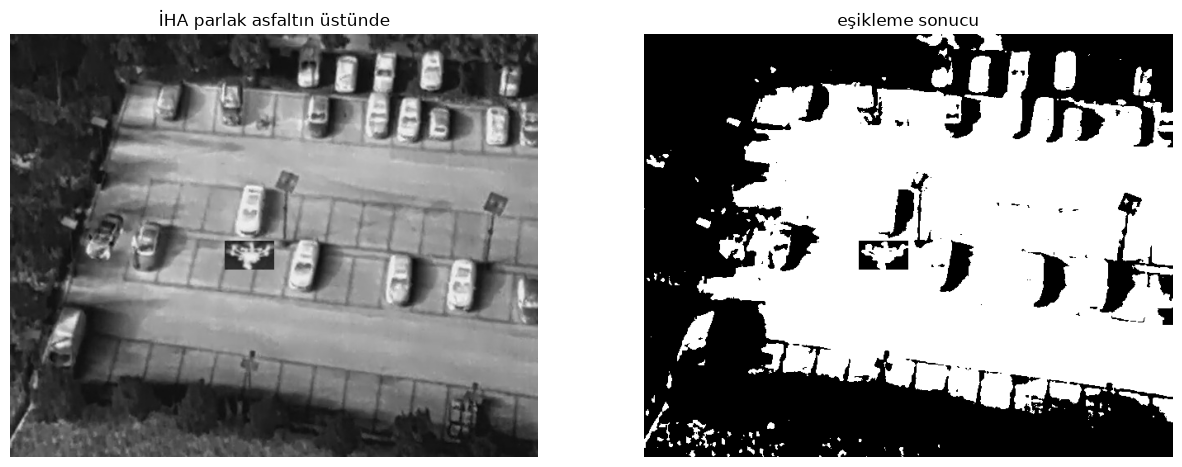

In [5]:
# =====================================================================
# İHA'yı otoparkın EN PARLAK yerine koy: güneşte ısınmış asfalt
# =====================================================================
kare = otopark.copy()
kare[250:250+ph, 260:260+pw] = parca        # asfaltın ortası, en parlak bölge

# --- 1) YOLO ne diyor? ---
sonuc = model(kare, verbose=False)[0]
droneler = [round(float(k.conf), 2) for k in sonuc.boxes
            if model.names[int(k.cls)] == "drone"]
print("YOLO → drone tahminleri:", droneler if droneler else "YOK")

# --- 2) Klasik yöntem ne diyor? ---
gri_kare = cv2.cvtColor(kare, cv2.COLOR_BGR2GRAY)
_, esik_kare = cv2.threshold(gri_kare, 0, 255,
                             cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# --- yan yana göster ---
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(kare, cv2.COLOR_BGR2RGB))
plt.title("İHA parlak asfaltın üstünde")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(esik_kare, cmap="gray", vmin=0, vmax=255)
plt.title("eşikleme sonucu")
plt.axis("off")
plt.show()

## Sonuç

- Video = kare dizisi. `VideoWriter` yazar, `VideoCapture` okur; arada kalan her şey bildiğimiz fotoğraf işleme.
- Model bir kareyi ~7-12 ms'de işliyor → saniyede 80-140 kare. Gerçek zamanlı video (25-30 FPS) için fazlasıyla yeterli.
- **Ana bulgu:** Aynı İHA, aynı hareket, iki farklı arka plan → 100/100 ve 0/100. Kestirme öğrenme video üzerinde de doğrulandı.

**Üretilen dosyalar** (`outputs/`, git'e girmiyor)

| Dosya | İçerik |
|---|---|
| `iha_video.mp4` | Gökyüzü arka planlı ham video |
| `iha_video_tespit.mp4` | Model kutularıyla → 100/100 |
| `iha_otopark.mp4` | Otopark arka planlı ham video |
| `iha_otopark_tespit.mp4` | Model kutularıyla → 0/100 |

**Sıradaki:** Veri setindeki ardışık karelerden **gerçek** termal video üretip nesne takibi (tracking) yapmak.